# M03. Predict PAs
- This predicts the outcome of plate appearances
- Type: Model
- Run Frequency: Irregular
- Sources:
    - MLB API
    - Steamer
- Created: 4/19/2024
- Updated: 5/3/2026

### Imports

In [1]:
from U01Imports import *
from U02Functions import *
from U03Classes import *
from U04Datasets import *
from U05Models import *

Using device: cuda


In [2]:
# Set option to display numbers without scientific notation
pd.set_option('display.float_format', '{:.6f}'.format)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Settings

In [4]:
wfx_type = 'unadj'  # Adjust WFX (calibrate). Options: 'adj' for adjusted, 'unadj' for unadjusted
min_venue_games = 81
training_min_date, training_max_date = '2022-01-01', '2025-12-30'
testing_min_date, testing_max_date =   '2026-01-01', '2026-07-19'

### Data

##### Park x Weather Factors

In [5]:
multiplier_df = pd.read_csv(os.path.join(baseball_path, "Park and Weather Factors (New).csv"))

Choose WFX
- _unadj: predicted based on weather / predicted based on batted ball <br>
- _adj: average of actual rates in similarly predicted games / predicted based on batted ball

In [6]:
for event in ['b1', 'b2', 'b3', 'hr', 'fo', 'go', 'po', 'lo']:
    multiplier_df[f'{event}_wfx_l'] = multiplier_df[f'{event}_wfx_{wfx_type}_l'].copy()
    multiplier_df[f'{event}_wfx_r'] = multiplier_df[f'{event}_wfx_{wfx_type}_r'].copy()

In [7]:
for event in ['so', 'bb', 'hbp']:
    multiplier_df[f'{event}_wfx_l'] = 1
    multiplier_df[f'{event}_wfx_r'] = 1

##### Plate Appearances

In [8]:
complete_dataset = pd.read_csv(os.path.join(baseball_path, "PA Dataset.csv"))

##### Steamer

In [9]:
steamer_hitters_df = pd.read_csv(os.path.join(baseball_path, "A03. Steamer", "Hitters", "Steamer Hitters Dataset.csv"), encoding='iso-8859-1')

In [10]:
steamer_pitchers_df = pd.read_csv(os.path.join(baseball_path, "A03. Steamer", "Pitchers", "Steamer Pitchers Dataset.csv"), encoding='iso-8859-1')

### Clean

##### MLB Stats API

Remove missings

In [11]:
complete_dataset = complete_dataset[~complete_dataset[batter_inputs].isin([np.inf, -np.inf]).any(axis=1)]
complete_dataset = complete_dataset[~complete_dataset[pitcher_inputs].isin([np.inf, -np.inf]).any(axis=1)]

Scale

In [12]:
%%time
complete_dataset[batter_inputs] = scale_batter_stats.transform(complete_dataset[batter_inputs])
complete_dataset[pitcher_inputs] = scale_pitcher_stats.transform(complete_dataset[pitcher_inputs])

CPU times: total: 688 ms
Wall time: 680 ms


Set data types

In [13]:
complete_dataset['date_time'] = pd.to_datetime(complete_dataset['date'], format='%Y%m%d')
complete_dataset['date_time_copy'] = complete_dataset['date_time'].copy()

complete_dataset['batter'] = complete_dataset['batter'].astype(int).astype(str)
complete_dataset['pitcher'] = complete_dataset['pitcher'].astype(int).astype(str)
complete_dataset['date'] = complete_dataset['date'].astype(str)
complete_dataset['venue_id'] = complete_dataset['venue_id'].astype(str)

Sort to prep for merge

In [14]:
complete_dataset.sort_values('date_time', inplace=True)

##### Steamer

Clean

In [15]:
steamer_hitters_df2 = clean_steamer_hitters(steamer_hitters_df).dropna(subset=batter_stats_fg)
steamer_pitchers_df2 = clean_steamer_pitchers(steamer_pitchers_df).dropna(subset=pitcher_stats_fg)

Scale

In [16]:
steamer_hitters_df2[batter_stats_fg] = scale_batter_stats_steamer.transform(steamer_hitters_df2[batter_stats_fg])
steamer_pitchers_df2[pitcher_stats_fg] = scale_pitcher_stats_steamer.transform(steamer_pitchers_df2[pitcher_stats_fg])

Remove missing pitchers (occurs occassionally in 2014)

In [17]:
steamer_pitchers_df2 = steamer_pitchers_df2[~steamer_pitchers_df2['mlbamid'].isna()].reset_index(drop=True)

Set data types

In [18]:
steamer_hitters_df2['date_time'] = pd.to_datetime(steamer_hitters_df2['date'], format='%Y%m%d')
steamer_pitchers_df2['date_time'] = pd.to_datetime(steamer_pitchers_df2['date'], format='%Y%m%d')

steamer_hitters_df2['mlbamid'] = steamer_hitters_df2['mlbamid'].astype(int).astype(str)
steamer_pitchers_df2['mlbamid'] = steamer_pitchers_df2['mlbamid'].astype(int).astype(str)

Rename for compatibility with MLB Stats API data

In [19]:
steamer_hitters_df2.rename(columns={'mlbamid': 'batter'}, inplace=True)
steamer_pitchers_df2.rename(columns={'mlbamid': 'pitcher'}, inplace=True)

Drop unnecessary columns

In [20]:
steamer_hitters_df2.drop(columns=['date', 'firstname', 'lastname', 'steamerid'], inplace=True)
steamer_pitchers_df2.drop(columns=['date', 'firstname', 'lastname', 'steamerid'], inplace=True)

Sort to prep for merge

In [21]:
steamer_hitters_df2.sort_values('date_time', inplace=True)
steamer_pitchers_df2.sort_values('date_time', inplace=True)

##### Multipliers

Fix data type

In [22]:
multiplier_df['venue_id'] = multiplier_df['venue_id'].astype(str)

In [23]:
multiplier_df['date'] = multiplier_df['date'].astype(str).str.replace("-", "")

In [24]:
multiplier_df.tail()

,gamePk,date,venue_id,temperature_2m,dew_point_2m,surface_pressure,meteo_x_vect,meteo_y_vect,rolling_carry_365d,b1_wfx_unadj_l,b1_wfx_unadj_r,b2_wfx_unadj_l,b2_wfx_unadj_r,b3_wfx_unadj_l,b3_wfx_unadj_r,fo_wfx_unadj_l,fo_wfx_unadj_r,go_wfx_unadj_l,go_wfx_unadj_r,hr_wfx_unadj_l,hr_wfx_unadj_r,lo_wfx_unadj_l,lo_wfx_unadj_r,po_wfx_unadj_l,po_wfx_unadj_r,woba_wfx_unadj_l,woba_wfx_unadj_r,venue_name,b1_wfx_l,b1_wfx_r,b2_wfx_l,b2_wfx_r,b3_wfx_l,b3_wfx_r,hr_wfx_l,hr_wfx_r,fo_wfx_l,fo_wfx_r,go_wfx_l,go_wfx_r,po_wfx_l,po_wfx_r,lo_wfx_l,lo_wfx_r,so_wfx_l,so_wfx_r,bb_wfx_l,bb_wfx_r,hbp_wfx_l,hbp_wfx_r
25828,824410,20260720,5,77.540000,62.690000,987.047240,-3.131802,-4.697698,401.163653,1.005329,0.986003,0.921061,0.952512,0.657083,1.110839,1.036512,1.020264,0.963807,0.994614,1.038520,0.954537,1.109416,1.053854,1.014059,1.015654,0.983238,0.972773,Progressive Field,1.005329,0.986003,0.921061,0.952512,0.657083,1.110839,1.038520,0.954537,1.036512,1.020264,0.963807,0.994614,1.014059,1.015654,1.109416,1.053854,1,1,1,1,1,1
25829,824654,20260720,17,79.700000,68.720000,986.948500,1.288676,13.715774,401.163653,1.008675,0.964656,0.842690,0.832033,1.017665,1.335167,1.005776,1.007406,0.976100,1.005464,1.441871,1.403055,1.059902,1.060189,0.821223,0.832209,1.085972,1.054906,Wrigley Field,1.008675,0.964656,0.842690,0.832033,1.017665,1.335167,1.441871,1.403055,1.005776,1.007406,0.976100,1.005464,0.821223,0.832209,1.059902,1.060189,1,1,1,1,1,1
25830,824736,20260720,3,79.160000,50.630000,1013.337340,-2.689071,9.016245,401.163653,1.020656,1.016415,1.022291,0.910671,0.841767,1.019783,1.024026,1.022731,0.986370,1.020392,0.942936,0.911489,1.024302,0.974277,0.937188,0.957732,0.994315,0.966296,Fenway Park,1.020656,1.016415,1.022291,0.910671,0.841767,1.019783,0.942936,0.911489,1.024026,1.022731,0.986370,1.020392,0.937188,0.957732,1.024302,0.974277,1,1,1,1,1,1
25831,824898,20260720,4705,88.520004,68.360000,976.775700,-3.336421,-7.494955,401.163653,1.028412,1.048980,0.894433,0.897494,0.521470,0.912822,1.069631,1.047063,0.963977,0.979035,0.997307,0.900869,1.055953,1.013637,0.980307,0.971147,0.973193,0.975255,Truist Park,1.028412,1.048980,0.894433,0.897494,0.521470,0.912822,0.997307,0.900869,1.069631,1.047063,0.963977,0.979035,0.980307,0.971147,1.055953,1.013637,1,1,1,1,1,1
25832,825058,20260720,15,70.000000,57.000000,969.201700,0.000000,0.000000,401.163653,1.040046,1.049721,0.822932,0.843300,1.137184,1.519748,1.110809,1.092501,0.964758,0.984458,0.810326,0.752865,1.071227,1.026071,0.915344,0.909974,0.937334,0.936407,Chase Field,1.040046,1.049721,0.822932,0.843300,1.137184,1.519748,0.810326,0.752865,1.110809,1.092501,0.964758,0.984458,0.915344,0.909974,1.071227,1.026071,1,1,1,1,1,1


Count number of games at venues

In [25]:
multiplier_df['venue_game_num'] = (
    multiplier_df.sort_values('date')
    .groupby('venue_id')
    .cumcount() + 1
)

### Merge

##### Merge #1. Plate Appearances and Steamer Batters

In [26]:
complete_dataset = pd.merge_asof(
    complete_dataset,
    steamer_hitters_df2,
    on='date_time',
    by='batter',
    direction='backward'
)

##### Merge #2. Add Steamer Pitchers 

In [27]:
complete_dataset = pd.merge_asof(
    complete_dataset,
    steamer_pitchers_df2,
    on='date_time',
    by='pitcher',
    direction='backward'
)

##### Merge #3. Add WFX

In [28]:
complete_dataset = pd.merge(complete_dataset, multiplier_df, on=['gamePk', 'date', 'venue_id'], how='left')

##### Free up memory

In [29]:
del steamer_hitters_df, steamer_hitters_df2, steamer_pitchers_df, steamer_pitchers_df2, multiplier_df

In [30]:
complete_dataset.tail()

,atBatIndex,inning,halfInning,outs,type,id,event,eventType,description,rbi,awayScore,homeScore,batter,batterName,batSide,pitcher,pitcherName,pitchHand,postOnFirst,postOnSecond,postOnThird,runner_id,start,end,movementReason,isScoringEvent,earned,gamePk,weather,wind,venue,date,away_name,home_name,game_date,game_type,venue_id,pitch_number,pitch_name,hc_x,hc_y,hit_location,totalDistance,launchSpeed,launch_angle,launch_speed_angle,woba_value,woba_denom,estimated_ba_using_speedangle,estimated_woba_using_speedangle,iso_value,babip_value,maxSpeed,maxSpin,temperature,windSpeed,windDirection,y_vect,x_vect,eventsModel,year,p_L,p_R,b_L,b_R,startingPitcher,starter,outs_pre,is_out,preOnFirst,preOnSecond,preOnThird,onFirst,onSecond,onThird,top,preAwayScore,preHomeScore,score_diff,batterScore,pitcherScore,preBatterScore,prePitcherScore,pa,ab,hard_hit,barrel,spray_angle,to_left,to_middle,to_right,to_l,to_lc,to_c,to_rc,to_r,h,tb,reached,faced,outs_total,outs_pa,b1_inning,b2_inning,b3_inning,bb_inning,fo_inning,go_inning,hbp_inning,hr_inning,lo_inning,po_inning,so_inning,h_inning,tb_inning,reached_inning,faced_inning,rbi_inning,outs_pa_inning,b1_game,b2_game,b3_game,bb_game,fo_game,go_game,hbp_game,hr_game,lo_game,po_game,so_game,h_game,tb_game,reached_game,faced_game,rbi_game,outs_pa_game,bottom,atBatIndex_min,first_ab,atBatIndex_max,pulled,times_faced,gamedate,mlbamid,PA,UBR600,b1_pred_batted,b2_pred_batted,b3_pred_batted,bb_pred_batted,fo_pred_batted,go_pred_batted,hbp_pred_batted,hr_pred_batted,lo_pred_batted,po_pred_batted,so_pred_batted,venue_id_adj,b1_b,b2_b,b3_b,bb_b,fo_b,go_b,hbp_b,hr_b,lo_b,po_b,so_b,estimated_woba_using_speedangle_b,to_left_b,to_middle_b,to_right_b,hard_hit_b,barrel_b,ab_b,pa_b,b1_p,b2_p,b3_p,bb_p,fo_p,go_p,hbp_p,hr_p,lo_p,po_p,so_p,estimated_woba_using_speedangle_p,to_left_p,to_middle_p,to_right_p,hard_hit_p,barrel_p,ab_p,pa_p,imp_b,imp_p,woba_b,woba_p,slg_b,slg_p,obp_b,obp_p,iso_b,iso_p,b1_b_long,b2_b_long,b3_b_long,bb_b_long,fo_b_long,go_b_long,hbp_b_long,hr_b_long,lo_b_long,po_b_long,so_b_long,iso_b_long,slg_b_long,obp_b_long,woba_b_long,estimated_woba_using_speedangle_b_long,to_left_b_long,to_middle_b_long,to_right_b_long,hard_hit_b_long,barrel_b_long,b1_p_long,b2_p_long,b3_p_long,bb_p_long,fo_p_long,go_p_long,hbp_p_long,hr_p_long,lo_p_long,po_p_long,so_p_long,iso_p_long,slg_p_long,obp_p_long,woba_p_long,estimated_woba_using_speedangle_p_long,to_left_p_long,to_middle_p_long,to_right_p_long,hard_hit_p_long,barrel_p_long,b1,b2,b3,bb,fo,go,hbp,hr,lo,po,so,date_time,date_time_copy,sb,sba,sbo,obp,slg,woba,b1_rate,b2_rate,b3_rate,hr_rate,bb_rate,hbp_rate,so_rate,H9,HR9,K9,BB9,GBrate,FBrate,LDrate,SIERA,IP_start,IP,relief_IP,temperature_2m,dew_point_2m,surface_pressure,meteo_x_vect,meteo_y_vect,rolling_carry_365d,b1_wfx_unadj_l,b1_wfx_unadj_r,b2_wfx_unadj_l,b2_wfx_unadj_r,b3_wfx_unadj_l,b3_wfx_unadj_r,fo_wfx_unadj_l,fo_wfx_unadj_r,go_wfx_unadj_l,go_wfx_unadj_r,hr_wfx_unadj_l,hr_wfx_unadj_r,lo_wfx_unadj_l,lo_wfx_unadj_r,po_wfx_unadj_l,po_wfx_unadj_r,woba_wfx_unadj_l,woba_wfx_unadj_r,venue_name,b1_wfx_l,b1_wfx_r,b2_wfx_l,b2_wfx_r,b3_wfx_l,b3_wfx_r,hr_wfx_l,hr_wfx_r,fo_wfx_l,fo_wfx_r,go_wfx_l,go_wfx_r,po_wfx_l,po_wfx_r,lo_wfx_l,lo_wfx_r,so_wfx_l,so_wfx_r,bb_wfx_l,bb_wfx_r,hbp_wfx_l,hbp_wfx_r,venue_game_num
1988040,32,5,top,2,atBat,665742,Flyout,field_out,Juan Soto flies out sharply to center fielder Garrett Mitchell.,0,1,0,665742,Juan Soto,L,687075,Brandon Sproat,R,NaN,NaN,NaN,665742,NaN,NaN,NaN,False,False,823760,Roof Closed.,"0 mph, Calm.",American Family Field.,20260721,New York Mets,Milwaukee Brewers,2026-07-21,R,32,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70,0,Calm,0.000000,0.000000,fo,2026,False,True,True,False,Brandon Sproat,1,1,1,NaN,NaN,NaN,0,0,0,1,1.000000,0.000000,1.000000,1,0,1.000000,0.000000,1,1,0,0,NaN,NaN,NaN,NaN,0,0,0,0,0,0.000000,0,0.000000,1,14,1,0,0,0,0,2,0,0,0,0,0,0,0.000000,0,0.000000,2,0,2,3,0,0,3,3,2,0,1,3,1,4,4.000000,7,7.000000,20,1,14,0,0,0,33,0,2.000000,2026-

### Impute

For players with insufficient sample sizes, stats are imputed

##### Option 1: Steamer

In [31]:
# # First, remove from dataset if ever missing FG/Steamer stats
# complete_dataset = complete_dataset[~complete_dataset['b1_rate'].isna()]
# complete_dataset = complete_dataset[~complete_dataset['H9'].isna()]

# # Add hands to use in imputation
# batter_stats_fg_imp = batter_stats_fg + ['b_L', 'p_L', 'imp_b']
# pitcher_stats_fg_imp = pitcher_stats_fg + ['b_L', 'p_L', 'imp_p']

# ### Batters
# # Use Steamer stats to predict API/Statcast stats for those with limited samples
# batter_predictions = impute_batter_stats.predict(complete_dataset.loc[complete_dataset['pa_b'] < 40, batter_stats_fg_imp])

# # Impute inputs with limited sample size with predicted values
# complete_dataset.loc[complete_dataset['pa_b'] < 40, batter_inputs] = batter_predictions

# ### Pitchers
# # Use Steamer stats to predict API/Statcast stats for those with limited samples
# pitcher_predictions = impute_pitcher_stats.predict(complete_dataset.loc[complete_dataset['pa_p'] < 40, pitcher_stats_fg_imp])

# # Impute inputs with limited sample size with predicted values
# complete_dataset.loc[complete_dataset['pa_p'] < 40, pitcher_inputs] = pitcher_predictions

##### Option 2: Middle

In [32]:
# # First, remove from dataset if ever missing FG/Steamer stats
# complete_dataset = complete_dataset[~complete_dataset['b1_rate'].isna()]
# complete_dataset = complete_dataset[~complete_dataset['H9'].isna()]

# # Instead of imputing, just weighting with 0s
# complete_dataset[batter_inputs].fillna(0.0, inplace=True)
# complete_dataset[pitcher_inputs].fillna(0.0, inplace=True)

# # Calculate the weighted average for each column in pitcher_stats
# # Could be simplified, but I wanted to show the steps
# # Weighted average of provided value and 0. PAs and 50-PAs are weights.
# for col in batter_inputs:
#     complete_dataset[col] = (complete_dataset[col] * complete_dataset['pa_b'] + 0.0 * (50-complete_dataset['pa_b']))/50

# # Calculate the weighted average for each column in pitcher_stats
# for col in pitcher_inputs:
#     complete_dataset[col] = (complete_dataset[col] * complete_dataset['pa_p'] + 0.0 * (50-complete_dataset['pa_p']))/50

##### Option 3: 0s and 1s

Assume 0s for player stats where sample is insufficient or missing

In [33]:
complete_dataset.loc[complete_dataset['pa_b'] < 40, batter_inputs] = 0
complete_dataset.loc[complete_dataset['pa_p'] < 40, pitcher_inputs] = 0

complete_dataset[batter_stats_fg] = complete_dataset[batter_stats_fg].fillna(0)
complete_dataset[pitcher_stats_fg] = complete_dataset[pitcher_stats_fg].fillna(0)

Assume 1 for WFX where WFX are missing

In [34]:
complete_dataset['imp_wfx'] = (complete_dataset['hr_wfx_l'].isna() | complete_dataset['hr_wfx_r'].isna()).astype(int)

In [35]:
complete_dataset[[f'{event}_wfx_l' for event in events_list]] = complete_dataset[[f'{event}_wfx_l' for event in events_list]].fillna(1)
complete_dataset[[f'{event}_wfx_r' for event in events_list]] = complete_dataset[[f'{event}_wfx_r' for event in events_list]].fillna(1)

### Sample

Drop early observations

In [36]:
complete_dataset = complete_dataset[(complete_dataset['game_date'] > training_min_date)]

Drop atypical events

In [37]:
complete_dataset = complete_dataset.query('eventsModel != "Cut"')

Drop observations from inactive parks

In [38]:
# complete_dataset = complete_dataset[complete_dataset['venue_id_adj'].astype(str).isin(venue_nums)]  # Taken from M01. Weather Factors but saved in U01. Imports

Drop early park observations

In [39]:
complete_dataset = complete_dataset[complete_dataset['venue_game_num'] > min_venue_games]

### Shift

Many batter and pitcher stats are calculated at the end of the plate appearance. For prediction purposes, we need these stats coming into the plate appearance.

##### Batter Inputs

Sort

In [40]:
complete_dataset.sort_values(['date', 'gamePk', 'atBatIndex'], ascending=True, inplace=True)

Shift

In [41]:
complete_dataset[batter_inputs + ['ab_b', 'pa_b', 'imp_b']] = complete_dataset.groupby(['batter', 'pitchHand'])[batter_inputs + ['ab_b', 'pa_b', 'imp_b']].shift(1)

##### Pitcher Inputs

Sort

In [42]:
complete_dataset.sort_values(['date', 'gamePk', 'atBatIndex'], ascending=True, inplace=True)

Shift

In [43]:
complete_dataset[pitcher_inputs + ['ab_p', 'pa_p', 'imp_p']] = complete_dataset.groupby(['pitcher', 'batSide'])[pitcher_inputs + ['ab_p', 'pa_p', 'imp_p']].shift(1)

##### Inning Sums

Sort

In [44]:
complete_dataset.sort_values(['date', 'gamePk', 'atBatIndex'], ascending=True, inplace=True)

Shift

In [45]:
cumulative_inning_input_list = [col for col in complete_dataset.columns if col.endswith("_inning")]

complete_dataset[cumulative_inning_input_list] = complete_dataset.groupby(['gamePk', 'inning', 'pitcher'])[cumulative_inning_input_list].shift(1)
complete_dataset[cumulative_inning_input_list] = complete_dataset[cumulative_inning_input_list].fillna(0)

##### Game Sums

Sort

In [46]:
complete_dataset.sort_values(['date', 'gamePk', 'atBatIndex'], ascending=True, inplace=True)

Shift

In [47]:
cumulative_game_input_list = [col for col in complete_dataset.columns if col.endswith("_game")]
cumulative_game_input_list.remove('rbi_game')

complete_dataset[cumulative_game_input_list + ['times_faced']] = complete_dataset.groupby(['gamePk', 'pitcher'])[cumulative_game_input_list + ['times_faced']].shift(1)
complete_dataset[cumulative_game_input_list + ['times_faced']] = complete_dataset[cumulative_game_input_list + ['times_faced']].fillna(0)

### Train/Test Split

Create masks to identify training and testing datasets <br>

Approach: 
- If you're testing new parameters, train on data through year - 1. Test on year. This will be the best model at testing out of sample, looking forward.
- If you're comfortable with model parameters, train on all data. Test on the most recent year. This ensures you're using the most data possible and biasing toward recent performance.

In [48]:
training_mask = ((complete_dataset['game_date'] >= training_min_date) & (complete_dataset['game_date'] <= training_max_date)).astype(bool)
testing_mask = ((complete_dataset['game_date'] >= testing_min_date) & (complete_dataset['game_date'] <= testing_max_date)).astype(bool)

### Evaluations

##### Constructed Stats

This builds stats used for evaluating model performance (actual event rates, FP, wOBA, outs)

In [49]:
def constructed_stats(complete_dataset):
    # Actual Stats
    for event in events_list:
        complete_dataset[f'{event}_act'] = (complete_dataset['eventsModel'] == event).astype(int)

    # FP - Pitchers
    pitcher_weights = {'fo': 1.0460, 'go': 1.0460, 'po': 1.0460, 'lo': 1.0460, 'so': 3.0408, 'bb': -1.3508, 'b1': -1.7427, 'b2': -1.7427, 'b3': -1.7427, 'hr': -3.6639}
    for suffix in ['act', 'pred']:
        complete_dataset.loc[testing_mask, f'FP_P_{suffix}'] = sum(
            complete_dataset.loc[testing_mask, f'{col}_{suffix}'] * w
            for col, w in pitcher_weights.items()
        )

    # FP - Batters
    batter_weights = {'b1': 4.3665, 'b2': 6.8271, 'b3': 10.8503, 'hr': 15.2611, 'bb':  2.8725, 'hbp': 2.9639}
    for suffix in ['act', 'pred']:
        complete_dataset.loc[testing_mask, f'FP_B_{suffix}'] = sum(
            complete_dataset.loc[testing_mask, f'{col}_{suffix}'] * w
            for col, w in batter_weights.items()
        )

    # wOBA (roughly)
    woba_weights = {'b1': 0.882, 'b2': 1.254, 'b3': 1.590, 'hr': 2.050, 'bb': 0.689, 'hbp': 0.720}
    for suffix in ['act', 'pred']:
        complete_dataset.loc[testing_mask, f'wOBA_{suffix}'] = sum(
            complete_dataset.loc[testing_mask, f'{col}_{suffix}'] * w
            for col, w in woba_weights.items()
        )

    # Out
    complete_dataset['is_out_act'] = complete_dataset['is_out'].copy()
    complete_dataset.loc[testing_mask, 'is_out_pred'] = complete_dataset.loc[testing_mask, ['fo_pred','go_pred','po_pred','lo_pred','so_pred']].sum(axis=1)


    return complete_dataset

##### Summary Statistics

In [50]:
def summary_statistics(complete_dataset, parameters, filename, le, show_venue_table=False):
    """
    Summary statistics computed on the testing window (testing_mask) only.
    One row per output. Rebuilds per-output quantile dataframes ({var}_df)
    used by graph_by_quantile.
    """
    output_vars = list(le.classes_) + ['is_out', 'wOBA', 'FP_B', 'FP_P']
    quantiles = 10
    test_df = complete_dataset[testing_mask]

    # Figure 1 – Pitchers: starter/imputation
    print("\nFigure 1: Pitchers by Starter and Imputation Status")
    print(test_df.groupby(['imp_p', 'starter'])[['FP_P_pred', 'FP_P_act', 'wOBA_act', 'so_act']].mean())

    # Figure 2 – Pitchers: imputation only
    print("\nFigure 2: Pitchers by Imputation Status")
    print(test_df.groupby(['imp_p'])[['FP_P_pred', 'FP_P_act', 'wOBA_act', 'so_act']].mean())

    # Figure 3 – Batters by Imputation Status
    print("\nFigure 3: Batters by Imputation Status")
    print(test_df.groupby(['imp_b'])[['FP_B_pred', 'FP_B_act', 'wOBA_act', 'hr_act']].mean())

    # Figure 4 – FP by Venue
    print("\nFigure 4: FP by Venue")
    venue_cols = ['FP_B_pred', 'FP_B_act', 'FP_P_pred', 'FP_P_act']
    means = test_df.groupby('venue_id')[venue_cols].mean()
    print(means)
    print(f"FP_B MSE: {np.mean((means['FP_B_pred'] - means['FP_B_act'])**2):.4f}")
    print(f"FP_P MSE: {np.mean((means['FP_P_pred'] - means['FP_P_act'])**2):.4f}")

    # Figure 5 – PA Outcome Multipliers by Venue
    if show_venue_table:
        print("\nFigure 5: PA Outcome Multipliers by Venue and Batter Side (pred and act vs league avg)")

        pitcher_weights_pa = {'fo': 1.0460, 'go': 1.0460, 'po': 1.0460, 'lo': 1.0460, 'so': 3.0408, 'bb': -1.3508, 'b1': -1.7427, 'b2': -1.7427, 'b3': -1.7427, 'hr': -3.6639}
        batter_weights_pa  = {'b1': 4.3665, 'b2': 6.8271, 'b3': 10.8503, 'hr': 15.2611, 'bb': 2.8725, 'hbp': 2.9639}
        woba_weights_pa    = {'b1': 0.882,  'b2': 1.254,  'b3': 1.590,   'hr': 2.050,   'bb': 0.689,  'hbp': 0.720}

        oos_df = test_df.copy()
        oos_df['batSide'] = np.where(oos_df['b_L'] == 1, 'L', 'R')

        league_pred = oos_df.groupby('batSide')[[f'{e}_pred' for e in events_list]].mean()
        league_act  = oos_df.groupby('batSide')[[f'{e}_act'  for e in events_list]].mean()

        venue_rows = []
        for (venue, side), grp in oos_df.groupby(['venue_id', 'batSide']):
            if len(grp) < 20:
                continue
            row = {'venue_id': venue, 'batSide': side, 'n': len(grp)}
            lp = league_pred.loc[side]
            la = league_act.loc[side]
            for e in events_list:
                row[f'{e}_pred_mult'] = grp[f'{e}_pred'].mean() / lp[f'{e}_pred'] if lp[f'{e}_pred'] > 0 else np.nan
                row[f'{e}_act_mult']  = grp[f'{e}_act'].mean()  / la[f'{e}_act']  if la[f'{e}_act']  > 0 else np.nan

            for suffix, league in [('pred', lp), ('act', la)]:
                for metric, weights in [('wOBA', woba_weights_pa), ('FP_B', batter_weights_pa), ('FP_P', pitcher_weights_pa)]:
                    numer_p = denom_p = 0.0
                    for e, w in weights.items():
                        rate = league[f'{e}_{suffix}'] if f'{e}_{suffix}' in league.index else 0
                        if rate > 0:
                            numer_p += abs(w) * rate * row[f'{e}_{suffix}_mult']
                            denom_p += abs(w) * rate
                    row[f'{metric}_{suffix}_mult'] = numer_p / denom_p if denom_p else np.nan
            venue_rows.append(row)

        venue_mult_df = pd.DataFrame(venue_rows).sort_values(['venue_id', 'batSide']).reset_index(drop=True)

        mult_cols_pred = [f'{e}_pred_mult' for e in events_list] + ['wOBA_pred_mult', 'FP_B_pred_mult', 'FP_P_pred_mult']
        mult_cols_act  = [f'{e}_act_mult'  for e in events_list] + ['wOBA_act_mult',  'FP_B_act_mult',  'FP_P_act_mult']
        display_cols_pa = ['venue_id', 'batSide', 'n'] + mult_cols_pred + mult_cols_act

        def style_mult(val):
            if not isinstance(val, float):
                return ''
            dev = val - 1.0
            intensity = min(int(abs(dev) * 400), 180)
            if dev > 0:
                return f'background-color: rgba(0,180,0,{intensity/255:.2f})'
            elif dev < 0:
                return f'background-color: rgba(220,0,0,{intensity/255:.2f})'
            return ''

        display(venue_mult_df[display_cols_pa].style
            .applymap(style_mult, subset=mult_cols_pred + mult_cols_act)
            .format({'n': '{:.0f}'})
            .format({col: '{:.3f}' for col in mult_cols_pred + mult_cols_act})
            .set_caption('PA Outcome Multipliers by Venue and Batter Side vs League Avg (Test)'))

    # Figure 6 – HR by WFX quantile
    print("\nFigure 5: HRs by Quantile")
    complete_dataset['hr_wfx_quantile'] = (pd.qcut(complete_dataset['hr_wfx'], q=quantiles, duplicates='drop', labels=False) + 1)
    print(complete_dataset[testing_mask].groupby('hr_wfx_quantile')[['hr_pred', 'hr_act']].mean())

    # Quantile performance tables + all_stat_df (test window only)
    all_stat_list = []

    for var in output_vars:
        pred_col = f"{var}_pred"
        act_col  = f"{var}_act"
        q_col    = f"{var}_quantile"

        # Assign quantile column on the test rows
        complete_dataset.loc[testing_mask, q_col] = pd.qcut(
            complete_dataset.loc[testing_mask, pred_col], quantiles, labels=False, duplicates='drop')

        # Quantile table on the test window
        df_test = (complete_dataset[testing_mask]
                   .groupby(q_col)[[act_col, pred_col]].mean().reset_index())
        mse_test = ((df_test[act_col] - df_test[pred_col]) ** 2).mean()

        # Aggregate stats (test window)
        actual    = complete_dataset.loc[testing_mask, act_col].mean()
        predicted = complete_dataset.loc[testing_mask, pred_col].mean()
        mult      = actual / predicted if predicted else np.nan
        stdev     = complete_dataset.loc[testing_mask, pred_col].std()

        all_stat_list.append(['Test', var, actual, predicted, mult, stdev, mse_test,
                              filename, str(parameters['hidden_layer_sizes'])])

        # Per-variable quantile dataframe for graph_by_quantile (suffix '')
        globals()[f"{var}_df"] = df_test

    all_stat_df = pd.DataFrame(all_stat_list,
        columns=['Year', 'Output', 'Actual', 'Predicted', 'Multiplier', 'Std. Dev', 'MSE', 'File', 'Layers'])

    print(all_stat_df[['Year','Output','Actual','Predicted','Multiplier','Std. Dev','MSE']])

    return all_stat_df


##### Plots

In [51]:
def graph_by_quantile(graph, le):
    """
    Plot predicted vs actual values by quantile for outputs.
    graph: a string suffix used in globals() variable names (e.g., '')
    le: LabelEncoder with class names
    """
    rows, columns = 5, 3
    fig, axs = plt.subplots(rows, columns, figsize=(columns*4, rows*4))

    total_plots = rows * columns
    output_vars = list(le.classes_) + ['is_out','wOBA','FP_B','FP_P']
    output_vars = output_vars[:total_plots]

    for i, var in enumerate(output_vars):
        row = i // columns
        col = i % columns
        df_name = f"{var}{graph}_df"
        if df_name not in globals():
            print(f"Warning: dataframe {df_name} not found, skipping")
            continue
        df = globals()[df_name]
        axs[row, col].plot(df[f'{var}_quantile'], df[f'{var}_pred'], color='red', label='Predicted')
        axs[row, col].plot(df[f'{var}_quantile'], df[f'{var}_act'], color='black', label='Actual')
        axs[row, col].set_title(var)
        axs[row, col].legend()

    fig.tight_layout(pad=2.0)
    plt.show()

### Model A. All - Unadjusted

##### Inputs

Batter Inputs

In [52]:
batter_input_list = batter_inputs

Remove directional proclivities

In [53]:
batter_input_list = [stat for stat in batter_input_list if "to_" not in stat]

Pitcher Inputs

In [54]:
pitcher_input_list = pitcher_inputs

Remove directional proclivities

In [55]:
pitcher_input_list = [stat for stat in pitcher_input_list if "to_" not in stat]

Hand Inputs

In [56]:
hand_input_list = ['p_L', 'b_L']

Imputation Inputs

In [57]:
imp_input_list = ['imp_b', 'imp_p']

Starter Input(s)

In [58]:
starter_input_list = ['starter']

Cumulative Inning Inputs

In [59]:
cumulative_inning_input_list = [col for col in complete_dataset.columns if col.endswith("_inning")]

In [60]:
cumulative_inning_input_list.remove('rbi_inning')

Cumulative Game Inputs

In [61]:
cumulative_game_input_list = [col for col in complete_dataset.columns if col.endswith("_game")]

In [62]:
cumulative_game_input_list.remove('rbi_game')

Game State Inputs

In [63]:
complete_dataset['winning'] = (complete_dataset['preBatterScore'] > complete_dataset['prePitcherScore']).astype(int)
complete_dataset['winning_big'] = (complete_dataset['preBatterScore'] > complete_dataset['prePitcherScore'] + 3).astype(int)

In [64]:
game_state_input_list = ['onFirst', 'onSecond', 'onThird', 'top', 'score_diff', 'prePitcherScore', 'preBatterScore', 'winning', 'winning_big', 'times_faced']

Inning Inputs

In [65]:
for inning in range(1, 12):
    complete_dataset[f'inning_{inning}'] = (complete_dataset['inning'] == inning).astype(int)
complete_dataset['inning_11'] = (complete_dataset['inning'] >= 11).astype(int)

In [66]:
inning_input_list = [col for col in complete_dataset.columns if col.startswith("inning_")]

Out Inputs

In [67]:
for out in range(0, 3):
    complete_dataset[f'outs_{out}'] = (complete_dataset['outs_pre'] == out).astype(int)

In [68]:
out_input_list = ['outs_0', 'outs_1', 'outs_2']

Venue Inputs

Note: venue inputs are not preferred following integrating into WFX

In [69]:
complete_dataset['venue_id2'] = complete_dataset['venue_id'].copy()
complete_dataset = pd.get_dummies(complete_dataset, columns=['venue_id2'], prefix='venue')

In [70]:
venue_dummy_list = [col for col in complete_dataset.columns if col.startswith("venue_") and col not in ["venue_id_adj", "venue_name",'venue_id']]
venue_dummy_list = list(dict.fromkeys(venue_dummy_list))

Assign batSide-specific Weather Multipliers

In [71]:
for event in events_list:
    complete_dataset[f'{event}_wfx'] = np.where(complete_dataset['batSide'] == "L", complete_dataset[f'{event}_wfx_l'],
                                                                                    complete_dataset[f'{event}_wfx_r'])

In [72]:
multiplier_input_list = [f'{event}_wfx' for event in events_list]

Imputation and starter interactions

In [73]:
complete_dataset['imputed_starter'] = complete_dataset['imp_p'] * complete_dataset['starter']
complete_dataset['imputed_reliever'] = complete_dataset['imp_p'] * (complete_dataset['starter'] == 0).astype(int)
complete_dataset['unimputed_starter'] = (complete_dataset['imp_p'] == 0).astype(int) * complete_dataset['starter']
complete_dataset['unimputed_reliever'] = (complete_dataset['imp_p'] == 0).astype(int) * (complete_dataset['starter'] == 0).astype(int)

In [74]:
imp_starter_input_list = ['imputed_starter', 'imputed_reliever', 'unimputed_starter', 'unimputed_reliever']

Model Inputs

In [75]:
model_a_input_list = (batter_input_list + pitcher_input_list + hand_input_list + imp_input_list + starter_input_list +
                      cumulative_inning_input_list + cumulative_game_input_list + game_state_input_list +
                      inning_input_list + out_input_list + imp_starter_input_list + batter_stats_fg + pitcher_stats_fg)

In [76]:
n1 = len(model_a_input_list) + 1

Fill in missings

In [77]:
complete_dataset[model_a_input_list] = complete_dataset[model_a_input_list].fillna(0)

Outputs

In [78]:
output_list = ['is_out', 'eventsModel']

Other variables

In [79]:
additional_list = ['pa_b', 'pa_p', 'year', 'date', 'gamePk', 'atBatIndex', 'venue_id', 'batterName', 'pitcherName', 'imp_wfx']

Variables to keep

In [80]:
keep_list = model_a_input_list + output_list + multiplier_input_list + additional_list

### Testing

Log Transform WFX Multipliers

In [81]:
complete_dataset[[f"{c}_log" for c in multiplier_input_list]] = complete_dataset[multiplier_input_list].apply(lambda col: np.log(col.clip(1e-9)))
log_wfx_cols    = [f"{c}_log" for c in multiplier_input_list]

One model, all inputs

In [82]:
model_a_input_list = (batter_input_list + pitcher_input_list + hand_input_list + imp_input_list + starter_input_list + 
                      cumulative_inning_input_list + cumulative_game_input_list + game_state_input_list + 
                      inning_input_list + out_input_list + imp_starter_input_list + batter_stats_fg + pitcher_stats_fg + log_wfx_cols)

##### Memory

Remove unnecessary columns

In [83]:
complete_dataset = complete_dataset[keep_list + log_wfx_cols]

Convert boolean columns to float

In [84]:
bool_cols = complete_dataset.select_dtypes(include="bool").columns
complete_dataset[bool_cols] = complete_dataset[bool_cols].astype(float)

##### Neural Network

PyTorch MLP

Train MLP classifier using PyTorch

In [85]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size):
        super().__init__()
        layers = []
        prev_size = input_size
        for h in hidden_layers:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            prev_size = h
        layers.append(nn.Linear(prev_size, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

Numpy Prediction (with sklearn syntax)

A copy of this class needs to go in U05. Models

In [86]:
class NumpyPredict:
    def __init__(self, ensemble_numpy, input_columns, classes, metadata=None):
        """
        ensemble_numpy: list of models, each a list of [W1, b1, W2, b2, ..., Wn, bn]
        input_columns: list of feature names used during training (order matters!)
        classes: list of class labels (same order as in training)
        metadata: optional dict with additional info (hidden_layers, num_classifiers, etc.)
        """
        self.ensemble = ensemble_numpy
        self.input_columns = input_columns
        self.classes_ = classes
        self.metadata = metadata or {}

    @staticmethod
    def _softmax(x):
        e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return e_x / e_x.sum(axis=1, keepdims=True)

    @staticmethod
    def _forward(model_layers, x):
        """
        Forward pass for a single model.
        model_layers: [W1, b1, W2, b2, ..., Wn, bn]
        x: numpy array of shape [n_samples, n_features]
        """
        h = x
        n_layers = len(model_layers) // 2

        # Apply all hidden layers with ReLU
        for i in range(n_layers - 1):
            W = model_layers[2*i]
            b = model_layers[2*i + 1]
            h = np.maximum(0, h @ W + b)

        # Final layer = output
        W = model_layers[-2]
        b = model_layers[-1]
        logits = h @ W + b
        return NumpyPredict._softmax(logits)

    def predict_proba(self, X):
        """
        X: pandas DataFrame, Series, or NumPy array
        Returns: numpy array [n_samples, n_classes] with probabilities
        """
        # Convert DataFrame or Series to NumPy array
        if isinstance(X, pd.DataFrame):
            x_np = X[self.input_columns].to_numpy(dtype=np.float32)
        elif isinstance(X, pd.Series):
            x_np = X[self.input_columns].to_numpy(dtype=np.float32).reshape(1, -1)
        else:
            x_np = np.array(X, dtype=np.float32)
            if x_np.ndim == 1:
                x_np = x_np.reshape(1, -1)

        # Check input size against first layer
        expected_size = self.ensemble[0][0].shape[0]
        if x_np.shape[1] != expected_size:
            raise ValueError(
                f"Input feature size ({x_np.shape[1]}) does not match model first layer ({expected_size})"
            )

        # Run all models in ensemble and average probabilities
        probs_list = [self._forward(model, x_np) for model in self.ensemble]
        avg_probs = np.mean(probs_list, axis=0)
        return avg_probs

    def predict(self, X):
        """
        Returns predicted class labels (argmax), like sklearn's predict()
        """
        probs = self.predict_proba(X)
        return np.array([self.classes_[i] for i in np.argmax(probs, axis=1)])


##### Settings

Model

In [87]:
num_classifiers = 3  # Ensemble size per config
n_runs = 10           # Number of random seed runs — best wOBA MSE is kept
graph = ''  # quantile-table suffix used by graph_by_quantile (test window)

all_stat_list = []  # Collects results across all configs

# ── Model A candidate configurations ─────────────────────────────────────────
# Each entry: hidden_layer_sizes, lr, alpha (weight decay), batch_size, max_iter
model_a_configs = {
    # Current winner — baseline for this round
    # "A_512x256_LowLR_e300":      {'hidden_layer_sizes': (512, 256),  'learning_rate_init': 0.001,  'alpha': 0,      'batch_size': 'auto', 'max_iter': 300},
    # # More epochs
    # "A_512x256_LowLR_e500":      {'hidden_layer_sizes': (512, 256),  'learning_rate_init': 0.001,  'alpha': 0,      'batch_size': 'auto', 'max_iter': 500},
    # # Even wider
    # "A_1024x512_LowLR_e300":     {'hidden_layer_sizes': (1024, 512), 'learning_rate_init': 0.001,  'alpha': 0,      'batch_size': 'auto', 'max_iter': 300},
    # Light regularization on winner
    "A_512x256_LowLR_Reg1e4":    {'hidden_layer_sizes': (512, 256),  'learning_rate_init': 0.001,  'alpha': 0.0001, 'batch_size': 'auto', 'max_iter': 300},
    # "A_512x256_LowLR_Reg1e3":    {'hidden_layer_sizes': (512, 256),  'learning_rate_init': 0.001,  'alpha': 0.001,  'batch_size': 'auto', 'max_iter': 300},
    # # Higher LR on winner
    # "A_512x256_e300":            {'hidden_layer_sizes': (512, 256),  'learning_rate_init': 0.01,   'alpha': 0,      'batch_size': 'auto', 'max_iter': 300},
}

Plots

In [88]:
quantiles = 10
graph = ''  # quantile-table suffix used by graph_by_quantile (test window)

##### Train, Predict, and Evaluate

In [89]:
# Encode outputs
le = LabelEncoder()
y_train_np = le.fit_transform(complete_dataset['eventsModel'].values[training_mask])
y_train = torch.tensor(y_train_np, dtype=torch.long, device=device)

X_train_np = complete_dataset.loc[training_mask, model_a_input_list].astype(float).values
X_train    = torch.tensor(X_train_np, dtype=torch.float32, device=device)
X_all_np   = complete_dataset[model_a_input_list].astype(float).values
X_all      = torch.tensor(X_all_np, dtype=torch.float32, device=device)

input_size  = X_train.shape[1]
output_size = len(le.classes_)

config_results_a    = {}
venue_mse_by_config = {}
best_run_by_config  = {}  # Tracks best random_state per config

for config_name, params in model_a_configs.items():
    print(f"\n{'='*60}")
    print(f"Model A Config: {config_name}")
    print(f"  layers={params['hidden_layer_sizes']}  lr={params['learning_rate_init']}  alpha={params['alpha']}")
    print(f"{'='*60}")

    best_woba_mse    = float('inf')
    best_random_state = None
    best_stat_df     = None
    best_venue_mse   = None

    for run_idx in range(n_runs):
        random_state = random.randint(10000, 90000)
        print(f"\n  Run {run_idx+1}/{n_runs} — random_state={random_state}")

        hidden_layers = params['hidden_layer_sizes']
        lr            = params['learning_rate_init']
        weight_decay  = params['alpha']
        num_epochs    = params['max_iter']
        ensemble      = []

        all_filename = f"predict_all_{''.join(str(x) for x in hidden_layers)}_{config_name}_{random_state}_{todaysdate}"

        for j in range(num_classifiers):
            seed = random_state + 100 * j
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
            np.random.seed(seed)
            random.seed(seed)

            model = MLP(input_size, hidden_layers, output_size).to(device)
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            criterion = nn.CrossEntropyLoss()

            model.train()
            for epoch in range(num_epochs):
                optimizer.zero_grad()
                outputs = model(X_train)
                loss = criterion(outputs, y_train)
                loss.backward()
                optimizer.step()

            ensemble.append(model)
            print(f"  ✓ Classifier {j+1}/{num_classifiers}")

        # Predict on full dataset
        with torch.no_grad():
            probs_list = [F.softmax(m(X_all), dim=1) for m in ensemble]
            avg_probs  = torch.stack(probs_list).mean(dim=0)

        all_outputs_pred = [c + "_pred" for c in le.classes_]
        complete_dataset.loc[:, all_outputs_pred] = avg_probs.cpu().numpy()

        # Capture venue MSE for this config before predictions are overwritten
        complete_dataset = constructed_stats(complete_dataset)
        venue_fp_config = (complete_dataset[testing_mask]
                           .groupby('venue_id')[['FP_B_pred', 'FP_B_act', 'FP_P_pred', 'FP_P_act']].mean())
        run_venue_mse = (
            np.mean((venue_fp_config['FP_B_pred'] - venue_fp_config['FP_B_act'])**2),
            np.mean((venue_fp_config['FP_P_pred'] - venue_fp_config['FP_P_act'])**2)
        )

        stat_df = summary_statistics(complete_dataset, parameters=params, filename=all_filename, le=le, show_venue_table=False)
        stat_df['Config'] = config_name

        # Track best run for this config by wOBA MSE
        run_woba_mse = stat_df[stat_df['Output'] == 'wOBA']['MSE'].values
        run_woba_mse = run_woba_mse[0] if len(run_woba_mse) else float('inf')
        is_best = run_woba_mse < best_woba_mse
        print(f"    wOBA MSE: {run_woba_mse:.6f}{'  ✓ New best!' if is_best else ''}")

        if is_best:
            best_woba_mse     = run_woba_mse
            best_random_state = random_state
            best_stat_df      = stat_df.copy()
            best_venue_mse    = run_venue_mse

            # Save PyTorch ensemble (only best run)
            torch.save({
                'state_dicts': [m.state_dict() for m in ensemble],
                'input_size': input_size,
                'hidden_layers': hidden_layers,
                'output_size': output_size
            }, os.path.join(model_path, "M03. Plate Appearances", f'{all_filename}.pt'))

            # Export NumpyPredict wrapper (only best run)
            ensemble_numpy = []
            for m in ensemble:
                layers = []
                for layer in [l for l in m.net if isinstance(l, nn.Linear)]:
                    W = layer.weight.detach().cpu().numpy().T
                    b = layer.bias.detach().cpu().numpy()
                    layers.extend([W.astype(np.float32), b.astype(np.float32)])
                ensemble_numpy.append(layers)

            predict_all_wrapper = NumpyPredict(
                ensemble_numpy=ensemble_numpy,
                input_columns=model_a_input_list,
                classes=le.classes_.tolist(),
                metadata={"hidden_layers": hidden_layers, "num_classifiers": num_classifiers,
                          "random_seed": random_state, "training_epochs": num_epochs}
            )
            pickle_filename = os.path.join(model_path, "M03. Plate Appearances", f"{all_filename}_wrapper.pkl")
            with open(pickle_filename, "wb") as f:
                pickle.dump(predict_all_wrapper, f)
            print(f"  Saved wrapper: {pickle_filename}")

    # Record best (skip configs where no run produced a valid wOBA MSE)
    if best_stat_df is None:
        print(f"\n  WARNING: {config_name} produced no valid run (wOBA MSE never finite) - skipping")
        continue
    best_run_by_config[config_name]  = best_random_state
    venue_mse_by_config[config_name] = best_venue_mse
    config_results_a[config_name]    = best_stat_df
    all_stat_list.append(best_stat_df)
    print(f"\n  Best random_state for {config_name}: {best_random_state} (wOBA MSE={best_woba_mse:.6f})")

# ── Model A comparison summary ────────────────────────────────────────────────
print("\n" + "="*60)
print("MODEL A — CONFIG COMPARISON SUMMARY")
print("="*60)

all_stat_df = pd.concat(all_stat_list, ignore_index=True)

comparison_rows = []
for config_name, stat_df in config_results_a.items():
    woba_year = stat_df[stat_df['Output'] == 'wOBA']
    fp_b_year = stat_df[stat_df['Output'] == 'FP_B']
    fp_p_year = stat_df[stat_df['Output'] == 'FP_P']
    venue_fp_b_mse, venue_fp_p_mse = venue_mse_by_config[config_name]

    comparison_rows.append({
        'Config':          config_name,
        'wOBA_MSE':        woba_year['MSE'].values[0]       if len(woba_year) else None,
        'wOBA_Mult':       woba_year['Multiplier'].values[0] if len(woba_year) else None,
        'wOBA_Std':        woba_year['Std. Dev'].values[0]   if len(woba_year) else None,
        'FP_B_MSE':        fp_b_year['MSE'].values[0]       if len(fp_b_year) else None,
        'FP_P_MSE':        fp_p_year['MSE'].values[0]       if len(fp_p_year) else None,
        'Venue_FP_B_MSE':  venue_fp_b_mse,
        'Venue_FP_P_MSE':  venue_fp_p_mse,
    })

comparison_df_a = pd.DataFrame(comparison_rows)

comparison_df_a['Rank_wOBA_MSE']       = comparison_df_a['wOBA_MSE'].rank()
comparison_df_a['Rank_FP_B_MSE']       = comparison_df_a['FP_B_MSE'].rank()
comparison_df_a['Rank_FP_P_MSE']       = comparison_df_a['FP_P_MSE'].rank()
comparison_df_a['Rank_Venue_FP_B_MSE'] = comparison_df_a['Venue_FP_B_MSE'].rank()
comparison_df_a['Rank_Venue_FP_P_MSE'] = comparison_df_a['Venue_FP_P_MSE'].rank()
comparison_df_a['Rank_wOBA_Std']       = comparison_df_a['wOBA_Std'].rank(ascending=False)

comparison_df_a['AvgRank'] = comparison_df_a[[
    'Rank_wOBA_MSE', 'Rank_FP_B_MSE', 'Rank_FP_P_MSE',
    'Rank_Venue_FP_B_MSE', 'Rank_Venue_FP_P_MSE', 'Rank_wOBA_Std'
]].mean(axis=1)

print(comparison_df_a[['Config', 'wOBA_MSE', 'wOBA_Mult', 'wOBA_Std',
                        'FP_B_MSE', 'FP_P_MSE',
                        'Venue_FP_B_MSE', 'Venue_FP_P_MSE', 'AvgRank']]
      .sort_values('AvgRank')
      .round(6)
      .to_string(index=False))

best_config_a = comparison_df_a.sort_values('AvgRank').iloc[0]['Config']
print(f"\n✓ Best Model A config: {best_config_a}")



Model A Config: A_512x256_LowLR_Reg1e4
  layers=(512, 256)  lr=0.001  alpha=0.0001

  Run 1/10 — random_state=70559
  ✓ Classifier 1/3
  ✓ Classifier 2/3
  ✓ Classifier 3/3

Figure 1: Pitchers by Starter and Imputation Status
                  FP_P_pred  FP_P_act  wOBA_act   so_act
imp_p    starter                                        
0.000000 0         0.602500  0.616850  0.309413 0.226338
         1         0.578388  0.602321  0.314957 0.221294
1.000000 0         0.472720  0.454778  0.340906 0.192614
         1         0.456106  0.450233  0.339079 0.184804

Figure 2: Pitchers by Imputation Status
          FP_P_pred  FP_P_act  wOBA_act   so_act
imp_p                                           
0.000000   0.588281  0.608282  0.312683 0.223363
1.000000   0.468473  0.453616  0.340439 0.190617

Figure 3: Batters by Imputation Status
          FP_B_pred  FP_B_act  wOBA_act   hr_act
imp_b                                           
0.000000   1.702103  1.699002  0.315169 0.030969
1.00000

##### Pareto-Optimal Models

In [90]:
all_stat_df = pd.concat(all_stat_list, ignore_index=True)

pareto_optimal(all_stat_df.query('Output == "wOBA"')
                          .query('1.03 > Multiplier > 0.97').reset_index(drop=True), ['MSE', 'Std. Dev'], ['Minimize', 'Maximize']).sort_values('Std. Dev')

,Year,Output,Actual,Predicted,Multiplier,Std. Dev,MSE,File,Layers,Config
0,Test,wOBA,0.314208,0.314289,0.999741,0.040065,0.000037,predict_all_512256_A_512x256_LowLR_Reg1e4_26652_20260722,"(512, 256)",A_512x256_LowLR_Reg1e4


##### Selected Model


Figure 1: Pitchers by Starter and Imputation Status
                  FP_P_pred  FP_P_act  wOBA_act   so_act
imp_p    starter                                        
0.000000 0         0.624459  0.616850  0.309413 0.226338
         1         0.608868  0.602321  0.314957 0.221294
1.000000 0         0.494149  0.454778  0.340906 0.192614
         1         0.480034  0.450233  0.339079 0.184804

Figure 2: Pitchers by Imputation Status
          FP_P_pred  FP_P_act  wOBA_act   so_act
imp_p                                           
0.000000   0.615265  0.608282  0.312683 0.223363
1.000000   0.490540  0.453616  0.340439 0.190617

Figure 3: Batters by Imputation Status
          FP_B_pred  FP_B_act  wOBA_act   hr_act
imp_b                                           
0.000000   1.698609  1.699002  0.315169 0.030969
1.000000   1.513371  1.556912  0.292366 0.023600

Figure 4: FP by Venue
          FP_B_pred  FP_B_act  FP_P_pred  FP_P_act
venue_id                                          
1      

,venue_id,batSide,n,b1_pred_mult,b2_pred_mult,b3_pred_mult,bb_pred_mult,fo_pred_mult,go_pred_mult,hbp_pred_mult,hr_pred_mult,lo_pred_mult,po_pred_mult,so_pred_mult,wOBA_pred_mult,FP_B_pred_mult,FP_P_pred_mult,b1_act_mult,b2_act_mult,b3_act_mult,bb_act_mult,fo_act_mult,go_act_mult,hbp_act_mult,hr_act_mult,lo_act_mult,po_act_mult,so_act_mult,wOBA_act_mult,FP_B_act_mult,FP_P_act_mult
0,1,L,1350,1.011,0.958,1.030,1.109,0.937,1.043,1.046,0.866,0.986,0.893,0.989,0.996,0.980,0.992,1.045,1.066,0.971,1.072,0.923,1.044,1.491,0.638,0.900,0.692,1.049,0.981,0.946,0.997
1,1,R,2373,0.919,0.957,0.998,1.111,0.965,0.918,1.037,1.101,0.902,0.964,1.138,1.000,1.005,1.037,0.955,0.778,0.890,0.976,1.042,0.890,1.586,0.842,0.959,0.893,1.190,0.924,0.909,1.031
2,12,L,1805,1.025,0.999,1.026,0.894,1.013,1.042,1.009,0.939,1.074,1.080,0.957,0.975,0.975,0.985,1.030,0.959,1.089,0.836,1.072,0.984,0.478,0.937,1.187,1.343,0.945,0.948,0.954,0.985
3,12,R,1867,1.023,1.031,1.005,0.946,1.027,1.018,0.977,1.018,1.051,1.052,0.940,1.008,1.011,0.986,0.985,1.271,0.905,0.868,0.959,1.049,1.072,1.285,1.053,1.187,0.885,1.073,1.101,0.984
4,14,L,1847,0.977,0.947,0.908,0.898,0.978,1.012,1.003,0.931,1.017,1.092,1.059,0.945,0.945,1.008,0.987,0.990,0.591,0.930,0.845,1.042,1.298,0.985,1.044,0.988,1.083,0.974,0.972,1.016
5,14,R,2077,0.991,0.974,0.934,1.004,1.022,0.992,0.983,1.005,1.027,1.098,0.977,0.991,0.992,0.993,1.015,0.958,0.407,1.022,0.951,0.993,0.694,1.011,0.938,1.189,1.021,0.989,0.989,1.008
6,15,L,1765,1.080,1.076,1.064,0.982,1.034,1.066,0.963,0.926,1.057,0.923,0.873,1.025,1.018,0.969,1.021,1.078,2.228,0.932,1.150,1.106,0.434,0.940,1.113,1.084,0.769,1.009,1.018,0.945
7,15,R,1821,1.077,1.057,1.054,0.950,1.040,1.069,0.963,0.877,1.063,0.950,0.879,1.009,1.000,0.968,1.057,0.987,2.552,0.903,1.073,1.132,0.703,0.860,1.089,1.057,0.809,0.985,0.984,0.949
8,17,L,1550,0.994,1.035,1.036,1.034,1.024,0.975,1.008,1.056,0.977,0.982,0.992,1.023,1.026,1.001,1.043,0.771,1.269,1.148,0.936,0.945,0.990,1.297,0.968,0.804,1.045,1.076,1.092,1.028
9,17,R,2252,1.011,1.034,1.009,1.014,1.091,0.979,0.982,1.058,1.042,1.102,0.909,1.024,1.027,0.980,1.037,0.777,1.501,1.113,1.098,0.985,0.924,1.065,1.126,1.088,0.868,1.015,1.016,0.970



Figure 5: HRs by Quantile
                 hr_pred   hr_act
hr_wfx_quantile                  
1               0.023777 0.020316
2               0.026824 0.027682
3               0.028144 0.029946
4               0.029464 0.030294
5               0.029881 0.027953
6               0.030283 0.031006
7               0.030872 0.031506
8               0.032156 0.036128
9               0.034207 0.039581
10              0.037005 0.041243
    Year  Output   Actual  Predicted  Multiplier  Std. Dev      MSE
0   Test      b1 0.140622   0.139918    1.005033  0.026027 0.000011
1   Test      b2 0.041366   0.042696    0.968852  0.006766 0.000005
2   Test      b3 0.003446   0.003924    0.878113  0.001164 0.000001
3   Test      bb 0.089561   0.089877    0.996480  0.034153 0.000012
4   Test      fo 0.135521   0.134661    1.006391  0.028737 0.000011
5   Test      go 0.220497   0.219425    1.004886  0.054120 0.000007
6   Test     hbp 0.011486   0.011422    1.005610  0.002977 0.000001
7   Test      hr 0.03

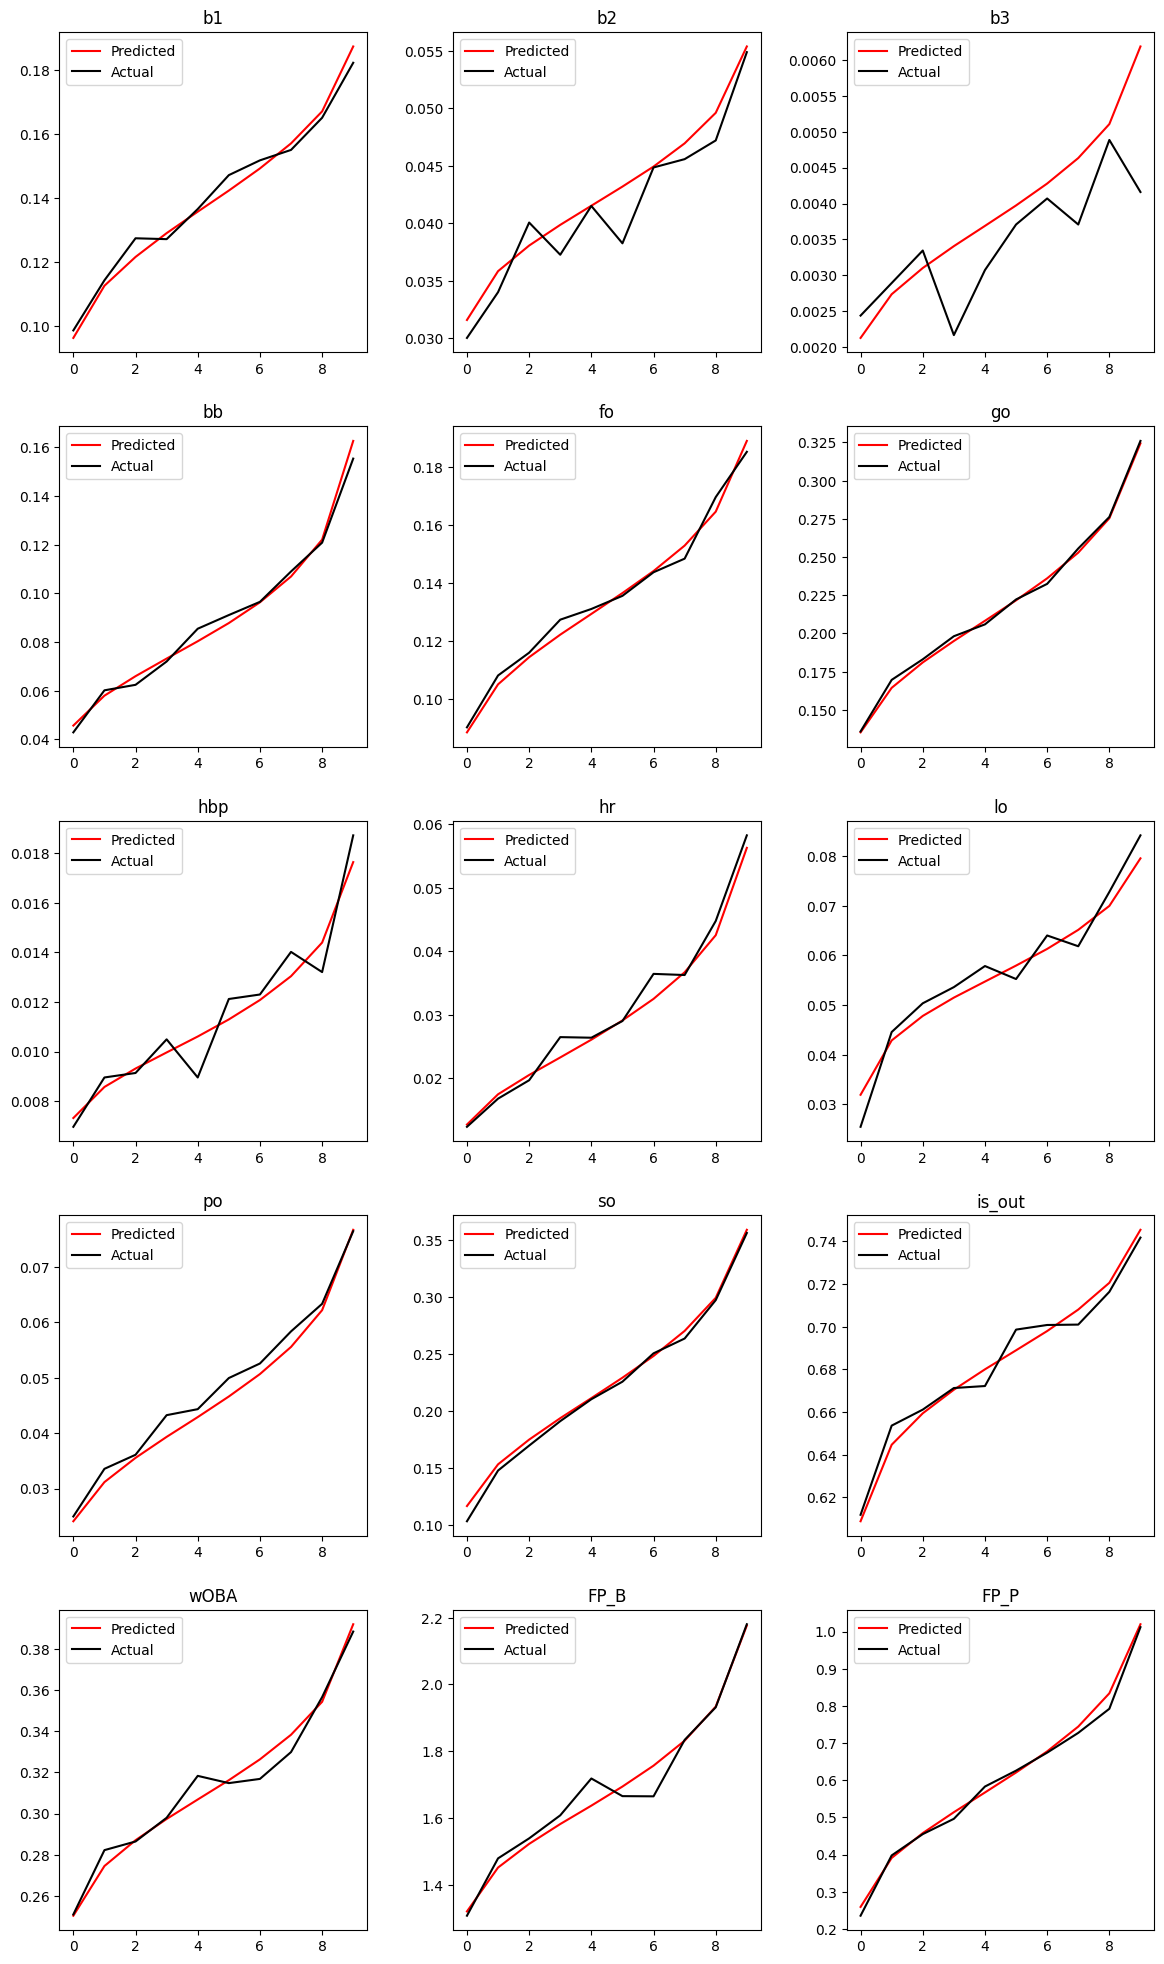

In [93]:
# ── Load model and display results ──────────────────────────────────────────
# Set the filename (without _wrapper.pkl) and run this cell to load, predict, and display

all_filename = "predict_all_512256_A_512x256_LowLR_Reg1e4_26652_20260722"  # ← set this

pickle_path = os.path.join(model_path, 'M03. Plate Appearances', f'{all_filename}_wrapper.pkl')
with open(pickle_path, 'rb') as f:
    loaded_wrapper = pickle.load(f)

# Predict on full dataset
all_outputs_pred = [c + '_pred' for c in le.classes_]
complete_dataset.loc[:, all_outputs_pred] = loaded_wrapper.predict_proba(complete_dataset[model_a_input_list])
complete_dataset = constructed_stats(complete_dataset)

# Display full summary and graphs
params = {**loaded_wrapper.metadata, 'hidden_layer_sizes': loaded_wrapper.metadata['hidden_layers']}
stat_df = summary_statistics(complete_dataset, parameters=params,
                             filename=all_filename, le=le, show_venue_table=True)
graph_by_quantile(graph, le=le)

In [92]:
raise SystemExit

SystemExit: 

### Predict

Load model

Note: this will overwrite predict_all model from U5. Models.ipynb

In [ ]:
all_filename = "predict_all_256128_61504_20251211"

# Path to the saved wrapper
pickle_file = os.path.join(model_path, "M03. Plate Appearances", f"{all_filename}_wrapper.pkl")

# Load the PredictAll wrapper
with open(pickle_file, "rb") as f:
    predict_all = pickle.load(f)

Predict

In [ ]:
all_outputs_pred = [x + "_pred1" for x in list(predict_all.classes_)]

complete_dataset[all_outputs_pred] = predict_all.predict_proba(complete_dataset[model_a_input_list])

In [ ]:
complete_dataset[all_outputs_pred].tail()

### Model B. All - WFX Adjusted

##### Inputs

Calculate Predicted Rate x WFX Interactions

In [ ]:
interactions_list = []

for event in events_list:
    complete_dataset[f'{event}_int'] = complete_dataset[f'{event}_pred1'] * complete_dataset[f'{event}_wfx']
    interactions_list.append(f'{event}_int')

In [ ]:
complete_dataset[[f"{c}_logit" for c in all_outputs_pred]] = complete_dataset[all_outputs_pred].apply(lambda col: np.log((col.clip(1e-9, 1-1e-9)) / (1 - col.clip(1e-9, 1-1e-9))))
complete_dataset[[f"{c}_log" for c in multiplier_input_list]] = complete_dataset[multiplier_input_list].apply(lambda col: np.log(col.clip(1e-9)))

In [ ]:
logit_base_cols = [f"{c}_logit" for c in all_outputs_pred]
log_wfx_cols    = [f"{c}_log"   for c in multiplier_input_list]

Model Inputs

In [ ]:
model_b_input_list = all_outputs_pred + multiplier_input_list + interactions_list + logit_base_cols + log_wfx_cols + imp_starter_input_list 

##### Settings

Model

In [ ]:
num_classifiers = 3  # Ensemble size per config
random_state = random.randint(10000, 90000)
graph = ''  # quantile-table suffix used by graph_by_quantile (test window)

all_adjusted_stat_list = []

# ── Model B candidate configurations ─────────────────────────────────────────
model_b_configs = {
    "B_32":          {'hidden_layer_sizes': (32,),      'learning_rate_init': 0.01,  'alpha': 1e-5, 'batch_size': 64, 'max_iter': 200},
    "B_64x32":       {'hidden_layer_sizes': (64, 32),   'learning_rate_init': 0.01,  'alpha': 1e-5, 'batch_size': 64, 'max_iter': 200},
    "B_128x64":      {'hidden_layer_sizes': (128, 64),  'learning_rate_init': 0.01,  'alpha': 1e-5, 'batch_size': 64, 'max_iter': 200},
    "B_32_HighReg":  {'hidden_layer_sizes': (32,),      'learning_rate_init': 0.01,  'alpha': 0.01, 'batch_size': 64, 'max_iter': 200},
    "B_64x32_LowLR": {'hidden_layer_sizes': (64, 32),   'learning_rate_init': 0.001, 'alpha': 1e-5, 'batch_size': 64, 'max_iter': 200},
    "B_32_LargeBatch":{'hidden_layer_sizes': (32,),     'learning_rate_init': 0.01,  'alpha': 1e-5, 'batch_size': 256,'max_iter': 200},
}

Plots

In [ ]:
quantiles = 10
graph = ''  # quantile-table suffix used by graph_by_quantile (test window)

##### Train, Predict, and Evaluate

In [ ]:
# Encode outputs
le = LabelEncoder()
y_train_np = le.fit_transform(complete_dataset['eventsModel'].values[training_mask])
y_train = torch.tensor(y_train_np, dtype=torch.long, device=device)

X_train_np = complete_dataset.loc[training_mask, model_b_input_list].astype(float).values
X_train    = torch.tensor(X_train_np, dtype=torch.float32, device=device)
X_test_np  = complete_dataset.loc[testing_mask, model_b_input_list].astype(float).values
X_test     = torch.tensor(X_test_np, dtype=torch.float32, device=device)

input_size  = X_train.shape[1]
output_size = len(le.classes_)

config_results_b = {}

for config_name, params in model_b_configs.items():
    print(f"\n{'='*60}")
    print(f"Model B Config: {config_name}")
    print(f"  layers={params['hidden_layer_sizes']}  lr={params['learning_rate_init']}  alpha={params['alpha']}  batch={params['batch_size']}")
    print(f"{'='*60}")

    hidden_layers = params['hidden_layer_sizes']
    lr            = params['learning_rate_init']
    weight_decay  = params['alpha']
    num_epochs    = params['max_iter']
    ensemble      = []

    all_adjusted_filename = f"predict_all_adjusted_{''.join(str(x) for x in hidden_layers)}_{random_state}_{todaysdate}"

    for j in range(num_classifiers):
        seed = random_state + 100 * j
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        np.random.seed(seed)
        random.seed(seed)

        model = MLP(input_size, hidden_layers, output_size).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = nn.CrossEntropyLoss()

        model.train()
        for epoch in range(num_epochs):
            optimizer.zero_grad()
            outputs = model(X_train)
            loss = criterion(outputs, y_train)
            loss.backward()
            optimizer.step()

        ensemble.append(model)
        print(f"  ✓ Classifier {j+1}/{num_classifiers}")

    # Save PyTorch ensemble
    torch.save({
        'state_dicts': [m.state_dict() for m in ensemble],
        'input_size': input_size,
        'hidden_layers': hidden_layers,
        'output_size': output_size
    }, os.path.join(model_path, "M03. Plate Appearances", f'{all_adjusted_filename}.pt'))

    # Export NumpyPredict wrapper
    ensemble_numpy = []
    for m in ensemble:
        layers = []
        for layer in [l for l in m.net if isinstance(l, nn.Linear)]:
            W = layer.weight.detach().cpu().numpy().T
            b = layer.bias.detach().cpu().numpy()
            layers.extend([W.astype(np.float32), b.astype(np.float32)])
        ensemble_numpy.append(layers)

    predict_all_adjusted_wrapper = NumpyPredict(
        ensemble_numpy=ensemble_numpy,
        input_columns=model_b_input_list,
        classes=le.classes_.tolist(),
        metadata={"hidden_layers": hidden_layers, "num_classifiers": num_classifiers,
                  "random_seed": random_state, "training_epochs": num_epochs}
    )
    pickle_filename = os.path.join(model_path, "M03. Plate Appearances", f"{all_adjusted_filename}_wrapper.pkl")
    with open(pickle_filename, "wb") as f:
        pickle.dump(predict_all_adjusted_wrapper, f)
    print(f"  Saved wrapper: {pickle_filename}")

    # Predict on test set
    with torch.no_grad():
        probs_list = [F.softmax(m(X_test), dim=1) for m in ensemble]
        avg_probs  = torch.stack(probs_list).mean(dim=0)

    all_adjusted_outputs_pred = [c + "_pred" for c in le.classes_]
    complete_dataset.loc[testing_mask, all_adjusted_outputs_pred] = avg_probs.cpu().numpy()

    complete_dataset = constructed_stats(complete_dataset)
    stat_df = summary_statistics(complete_dataset, parameters=params, filename=all_adjusted_filename, le=le)
    stat_df['Config'] = config_name
    all_adjusted_stat_list.append(stat_df)
    config_results_b[config_name] = stat_df
    graph_by_quantile(graph, le=le)

# ── Model B comparison summary ────────────────────────────────────────────────
print("\n" + "="*60)
print("MODEL B — CONFIG COMPARISON SUMMARY")
print("="*60)

all_adjusted_stat_df = pd.concat(all_adjusted_stat_list, ignore_index=True)

comparison_rows_b = []
for config_name, stat_df in config_results_b.items():
    woba_year = stat_df[stat_df['Output'] == 'wOBA']
    fp_b_year = stat_df[stat_df['Output'] == 'FP_B']
    fp_p_year = stat_df[stat_df['Output'] == 'FP_P']

    venue_fp = (complete_dataset[testing_mask]
                .groupby('venue_id')[['FP_B_pred', 'FP_B_act', 'FP_P_pred', 'FP_P_act']].mean())
    venue_fp_b_mse = np.mean((venue_fp['FP_B_pred'] - venue_fp['FP_B_act'])**2)
    venue_fp_p_mse = np.mean((venue_fp['FP_P_pred'] - venue_fp['FP_P_act'])**2)

    comparison_rows_b.append({
        'Config':         config_name,
        'wOBA_MSE':       woba_year['MSE'].values[0]       if len(woba_year) else None,
        'wOBA_Mult':      woba_year['Multiplier'].values[0] if len(woba_year) else None,
        'wOBA_Std':       woba_year['Std. Dev'].values[0]   if len(woba_year) else None,
        'FP_B_MSE':       fp_b_year['MSE'].values[0]       if len(fp_b_year) else None,
        'FP_P_MSE':       fp_p_year['MSE'].values[0]       if len(fp_p_year) else None,
        'Venue_FP_B_MSE': venue_fp_b_mse,
        'Venue_FP_P_MSE': venue_fp_p_mse,
    })

comparison_df_b = pd.DataFrame(comparison_rows_b)

comparison_df_b['Rank_wOBA_MSE']       = comparison_df_b['wOBA_MSE'].rank()
comparison_df_b['Rank_FP_B_MSE']       = comparison_df_b['FP_B_MSE'].rank()
comparison_df_b['Rank_FP_P_MSE']       = comparison_df_b['FP_P_MSE'].rank()
comparison_df_b['Rank_Venue_FP_B_MSE'] = comparison_df_b['Venue_FP_B_MSE'].rank()
comparison_df_b['Rank_Venue_FP_P_MSE'] = comparison_df_b['Venue_FP_P_MSE'].rank()
comparison_df_b['Rank_wOBA_Std']       = comparison_df_b['wOBA_Std'].rank(ascending=False)

comparison_df_b['AvgRank'] = comparison_df_b[[
    'Rank_wOBA_MSE', 'Rank_FP_B_MSE', 'Rank_FP_P_MSE',
    'Rank_Venue_FP_B_MSE', 'Rank_Venue_FP_P_MSE', 'Rank_wOBA_Std'
]].mean(axis=1)

print(comparison_df_b[['Config', 'wOBA_MSE', 'wOBA_Mult', 'wOBA_Std',
                        'FP_B_MSE', 'FP_P_MSE',
                        'Venue_FP_B_MSE', 'Venue_FP_P_MSE', 'AvgRank']]
      .sort_values('AvgRank')
      .round(6)
      .to_string(index=False))

best_config_b = comparison_df_b.sort_values('AvgRank').iloc[0]['Config']
print(f"\n✓ Best Model B config: {best_config_b}")


Pareto-Optimal Models

In [ ]:
all_adjusted_stat_df = pd.concat(all_adjusted_stat_list, ignore_index=True)

pareto_optimal(all_adjusted_stat_df.query(f'Year == {year}') # Will accept variable year and string "All"
                                   .query('Output == "wOBA"')
                                   .query('1.02 > Multiplier > 0.98').reset_index(drop=True), ['MSE', 'Std. Dev'], ['Minimize', 'Maximize']).sort_values('Std. Dev')

Note: We have the following options for predicting plate appearances using player, game, and weather inputs:
1. Kitchen Sink: One model with all features
2. Interacted Outputs: One model with player/game features. Outputs are then multiplied by wfx multipliers to create probabilities.
3. Split: Two models. First has player/game stats. Second has model 1 outputs and wfx multipliers as inputs.
4. Interacted Inputs: Two models. First has player/game stats. Second has model 1 outputs x wfx multipliers as inputs.
5. No Rain: One model with player/game stats. No wfx at all. (Just a baseline for comparison)